In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from keras._tf_keras.keras.utils import to_categorical


In [2]:
train_dir = "FER2013/train"
test_dir = "FER2013/test"

In [4]:
def load_data(data_dir, img_size=(48, 48)):
    X, y = [], []
    class_names = sorted(os.listdir(data_dir))  # sort for consistent label mapping
    class_map = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(class_map[cls])

    X = np.array(X, dtype="float32") / 255.0
    y = to_categorical(y, num_classes=len(class_names))
    return np.array(X), np.array(y), class_map


C:\Users\User\AppData\Local\Temp\ipykernel_25100\3965307371.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


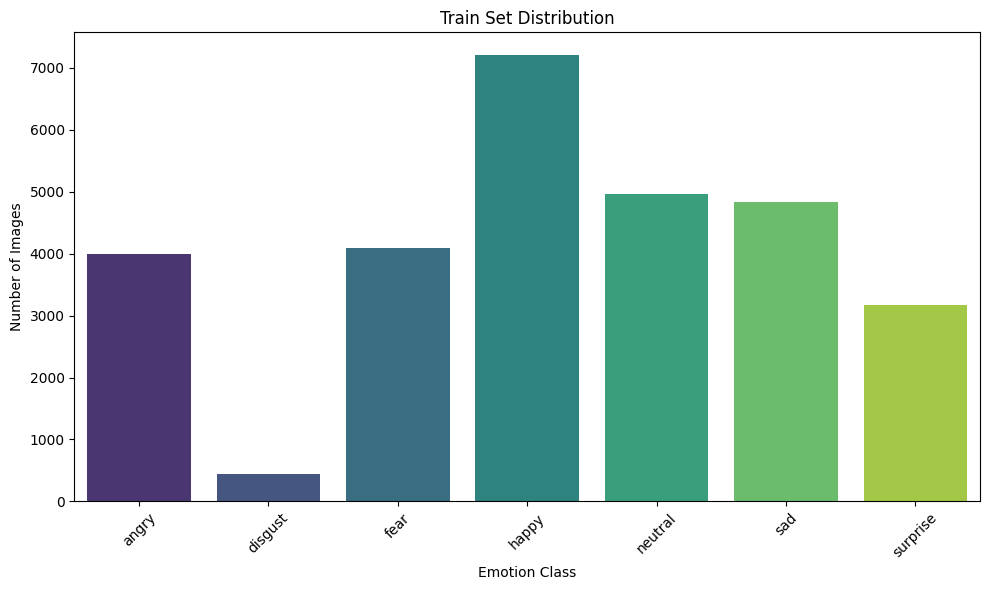

C:\Users\User\AppData\Local\Temp\ipykernel_25100\3965307371.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


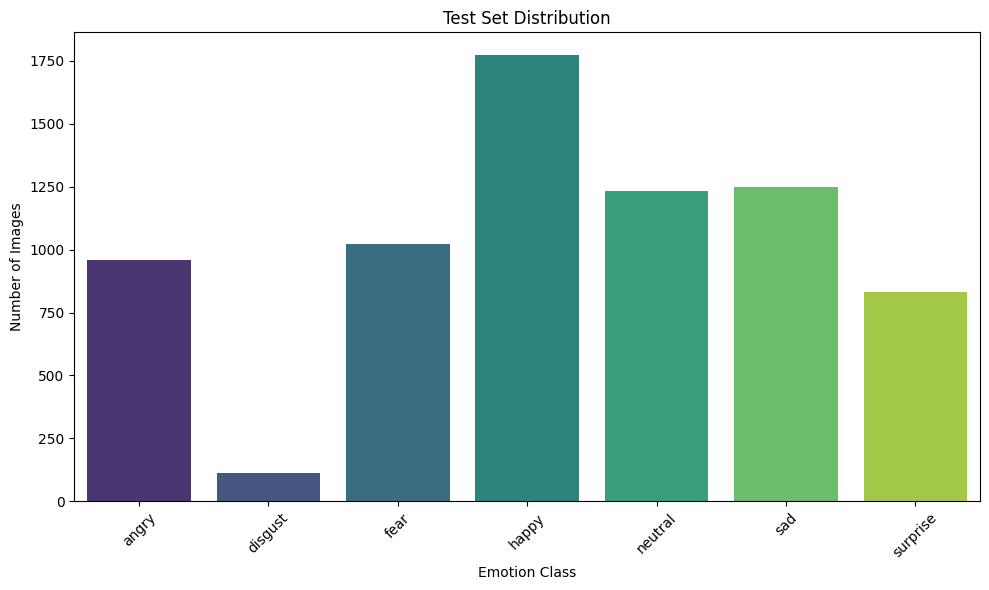

In [5]:
def plot_class_distribution(data_dir, title="Class Distribution"):
    class_counts = {}
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        class_counts[cls] = len(os.listdir(cls_path))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
    plt.title(title)
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_dir, title="Train Set Distribution")
plot_class_distribution(test_dir, title="Test Set Distribution")

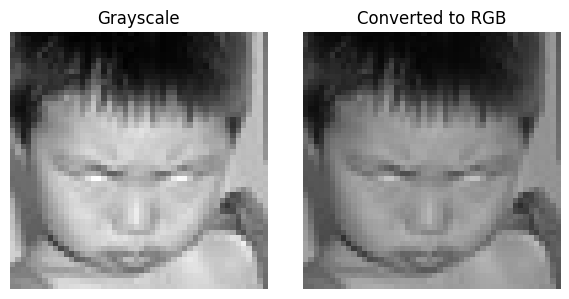

In [5]:
def visualize_rgb_conversion(data_dir, img_size=(48, 48)):
    class_dirs = os.listdir(data_dir)
    sample_class = class_dirs[0]
    img_path = os.path.join(data_dir, sample_class, os.listdir(os.path.join(data_dir, sample_class))[0])
    
    gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    rgb_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    gray_img = cv2.resize(gray_img, img_size)
    rgb_img = cv2.resize(rgb_img, img_size)

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_img, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(rgb_img)
    plt.title("Converted to RGB")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
visualize_rgb_conversion(train_dir)

In [10]:
def display_label_encoding(data_dir):
    class_names = sorted(os.listdir(data_dir))
    class_map = {cls_name: idx for idx, cls_name in enumerate(class_names)}
    
    print("Label Encoding Mapping:")
    for label, idx in class_map.items():
        print(f"  '{label}': {idx}")
    
    return class_map

class_map = display_label_encoding(train_dir)

Label Encoding Mapping:
  'angry': 0
  'disgust': 1
  'fear': 2
  'happy': 3
  'neutral': 4
  'sad': 5
  'surprise': 6


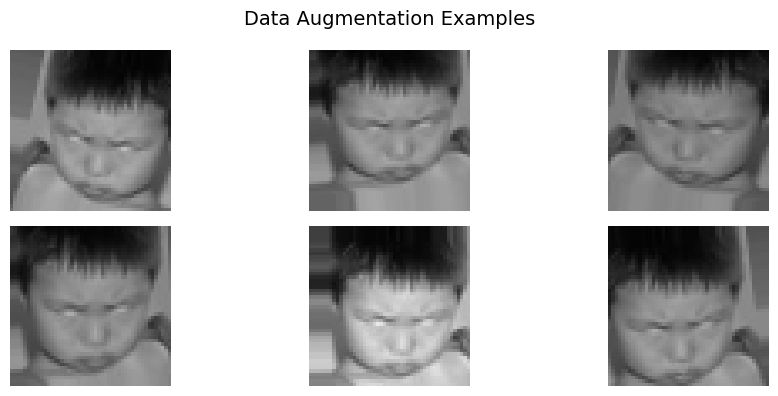

In [8]:
def visualize_augmentation(data_dir, img_size=(48, 48)):
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        brightness_range=[0.7, 1.3],
        horizontal_flip=True,
        fill_mode='nearest'
    )

    class_dirs = os.listdir(data_dir)
    sample_class = class_dirs[0]
    img_path = os.path.join(data_dir, sample_class, os.listdir(os.path.join(data_dir, sample_class))[0])

    img = cv2.imread(img_path)
    img = cv2.resize(img, img_size)
    img = img[np.newaxis, ...]

    it = datagen.flow(img, batch_size=1)

    plt.figure(figsize=(10, 4))
    for i in range(6):
        batch = next(it)[0]
        plt.subplot(2, 3, i + 1)
        plt.imshow(batch)
        plt.axis('off')
    plt.suptitle("Data Augmentation Examples", fontsize=14)
    plt.tight_layout()
    plt.show()
    
visualize_augmentation(train_dir)

In [9]:
def get_data_generator_rgb(train_dir, test_dir, img_size=(48, 48), batch_size=32):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=15,
        shear_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=[0.7, 1.3],
        horizontal_flip=True,
        fill_mode='nearest'
    )

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        subset='training',
        shuffle=True
    )

    val_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        subset='validation',
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = get_data_generator_rgb(train_dir, test_dir)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
